# Finetuning a Sentence Transformer Model

## Installing Libraries for this Notebook

In [1]:
!pip install -U transformers
!pip install -U sentence-transformers
!pip install datasets

!pip install evaluate
!pip install seqeval

I would like to note that, for this section, I did not make any changes to the model architecture itself or outside of it.
The SentenceTransformer model was designed specifically to work best with short-form inputs like sentences, passages and paragraphs.

There was also no need to change any hyperparameters of the model itself especially to encode input sentences into embeddings of a fixed-length, since the SentenceTransformer class outputs encodings to a fixed length of 768 encoding values.

More information on the hyperparameters may be found here:
https://www.sbert.net/docs/package_reference/sentence_transformer/SentenceTransformer.html#id1

# Step 2: Multi-Task Learning Expansion

In this section, I will be doing something a bit differently.

Instead of exclusively using the sBERT sentence_transformers library, I will switch over to using a few libraries, made available by HuggingFace, which will help import the datasets and set-up a sentence transformer model for Sentence Classification and Named Entity Recognition.


### Task A: Sentence Classification


In [2]:
import os
import json
import numpy as np
import pandas as pd
import torch
# Huggingface imports below
import datasets
from datasets import load_dataset, DatasetDict, Dataset
from transformers import AutoTokenizer, DataCollatorWithPadding
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from transformers import pipeline
from sentence_transformers import SentenceTransformer
import evaluate
import nltk
from nltk.tokenize import PunktTokenizer
import seaborn
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [3]:
# Importing "IMDb" dataset from Huggingface
imdb_ds = load_dataset("imdb")

# Display the structure of the dataset
print(imdb_ds)

# Display the 'training' split of the dataset
print(imdb_ds["train"])

# Initialize the NLTK Sentence Tokenizer
nltk.download('punkt_tab')
sentence_tokenizer = PunktTokenizer()

# Initialize a Sentence Transformer model
# In this case, I use one of the original models "all-mpnet-base-v2"
# which was trained on more than 1 billion training pairs
# and achieves the highest quantitative results against the other models.
# Those quantitative results may be viewed here:
# https://www.sbert.net/docs/sentence_transformer (link continued below)
# /pretrained_models.html#original-models
sentence_transformer_sbert_model = SentenceTransformer("all-mpnet-base-v2")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [4]:
# The tutorial from HuggingFace, https://huggingface.co/docs/transformers/en/tasks/sequence_classification
# The datasets that get fed during the training loop are first preprocessed
# I will preprocess the dataset in that way
# Then I will preprocess using the dataset as pandas dataframe

In [5]:
# I convert each dataset subset into pandas DataFrames
# This includes the 'train' subset for training, 'test' subset for testing, and the 'unsupervised' subset in order to find out what it is for.
imdb_train_ds = imdb_ds["train"].to_pandas()
imdb_test_ds = imdb_ds["test"].to_pandas()
imdb_unsupervised_ds = imdb_ds["unsupervised"].to_pandas()

In [6]:
# Both datasets are 25,000 samples long
print("The size of the training set is:", len(imdb_train_ds))
print("The size of the testing set is:", len(imdb_test_ds))

The size of the training set is: 25000
The size of the testing set is: 25000


In [7]:
# From our exploratory data analysis notebook
# To Do Item: Include screenshot of barplot from EDA notebook
# I want to split apart the overall texts into sentences, to find out how long every review is
# I will most likely drop the now separated sentences at the end, only needing to use how many sentences there were
# But I will hold onto them for now

# This function will accept an input dataframe
# And return the dataframe with two new columns
# A "sentences" column containing a list of sentences from the overall text column
# And a "num_sentences" column containing the number of sentences in that text.
def tokenize_into_sentences(input_dataframe):
  tokenized_sentences = []
  num_sentences = []

  output_dataframe = input_dataframe

  for entry in input_dataframe['text']:
    result_tokens = sentence_tokenizer.tokenize(entry)

    tokenized_sentences.append(result_tokens)
    num_sentences.append(len(result_tokens))


  output_dataframe["split_sentences"] = tokenized_sentences
  output_dataframe["num_sentences"] = num_sentences

  return output_dataframe

imdb_train_ds = tokenize_into_sentences(imdb_train_ds)
imdb_test_ds = tokenize_into_sentences(imdb_test_ds)

# I take a moment to reorganize the column order of the dataframe, so that label is the final column.
imdb_train_ds = imdb_train_ds.reindex(columns=['text', 'split_sentences', 'num_sentences', 'label'])
imdb_test_ds = imdb_test_ds.reindex(columns=['text', 'split_sentences', 'num_sentences', 'label'])


In [8]:
print(imdb_train_ds.head())

                                                text  \
0  I rented I AM CURIOUS-YELLOW from my video sto...   
1  "I Am Curious: Yellow" is a risible and preten...   
2  If only to avoid making this type of film in t...   
3  This film was probably inspired by Godard's Ma...   
4  Oh, brother...after hearing about this ridicul...   

                                     split_sentences  num_sentences  label  
0  [I rented I AM CURIOUS-YELLOW from my video st...              9      0  
1  ["I Am Curious: Yellow" is a risible and prete...             11      0  
2  [If only to avoid making this type of film in ...              3      0  
3  [This film was probably inspired by Godard's M...              7      0  
4  [Oh, brother...after hearing about this ridicu...              6      0  


In [9]:
print(imdb_test_ds.head())

                                                text  \
0  I love sci-fi and am willing to put up with a ...   
1  Worth the entertainment value of a rental, esp...   
2  its a totally average film with a few semi-alr...   
3  STAR RATING: ***** Saturday Night **** Friday ...   
4  First off let me say, If you haven't enjoyed a...   

                                     split_sentences  num_sentences  label  
0  [I love sci-fi and am willing to put up with a...             19      0  
1  [Worth the entertainment value of a rental, es...             11      0  
2  [its a totally average film with a few semi-al...              5      0  
3  [STAR RATING: ***** Saturday Night **** Friday...             11      0  
4  [First off let me say, If you haven't enjoyed ...              7      0  


In [10]:
# Based on the histogram plots in the other notebook
# To Do Item: Add the screenshot here
# A lot of the reviews are between 0 and 50 sentences
# With a significant amount of reviews that are longer than 50 sentences,
# With some as long as 200 or more sentences

# I will find out a value of num_sentences
# Where below that value, 80% of the data resides
# This is known as the 80th percentile or quantile value
imdb_train_ds_sentences_80_quantile = imdb_train_ds["num_sentences"].quantile(0.8)
imdb_test_ds_sentences_80_quantile = imdb_test_ds["num_sentences"].quantile(0.8)

print(f"""The 80th quantile/percentile for num_sentences in imdb_train_ds is: {imdb_train_ds_sentences_80_quantile}.
       So 80 percent of the reviews are shorter than {imdb_train_ds_sentences_80_quantile} sentences.""")
print(f"""The 80th quantile/percentile for num_sentences in imdb_test_ds is: {imdb_test_ds_sentences_80_quantile}.
       So 80 percent of the reviews are shorter than {imdb_test_ds_sentences_80_quantile} sentences.""")

The 80th quantile/percentile for num_sentences in imdb_train_ds is: 15.0.
       So 80 percent of the reviews are shorter than 15.0 sentences.
The 80th quantile/percentile for num_sentences in imdb_test_ds is: 14.0.
       So 80 percent of the reviews are shorter than 14.0 sentences.


In [11]:
# Here I will take the subsets of the datasets that are beneath the threshold.
# I will check the length of the dataset before the boolean slice is performed
print("The size of the training set is:", len(imdb_train_ds))
print("The size of the test set is:", len(imdb_test_ds))

imdb_train_ds = imdb_train_ds[imdb_train_ds["num_sentences"] <= imdb_train_ds_sentences_80_quantile]
imdb_test_ds = imdb_test_ds[imdb_test_ds["num_sentences"] <= imdb_test_ds_sentences_80_quantile]

# Then check the length again after the boolean slice is done.
print("The size of the training set, after taking those under the 80th quantile value, is:", len(imdb_train_ds))
print("The size of the test set, after taking those under the 80th quantile value, is:", len(imdb_test_ds))

The size of the training set is: 25000
The size of the test set is: 25000
The size of the training set, after taking those under the 80th quantile value, is: 20533
The size of the test set, after taking those under the 80th quantile value, is: 20037


In [12]:
# Both the training set and testing set are 25,000 samples long
# When using the free version of Google Colab,
# Training may take a very long time when using CPU only on the entire dataset.
# I saw an estimated completion time of around 170 hours, which is almost 8 days
# In some circumstances, the user may run out of GPU time to train the model.
# Update: A training set of 10,000 samples had an estimation to complete within
#         42 hours, which will cause the notebook session to timeout.

# In that case, I will create two runs.
# One run on the entirety of the provided data
# A second run on a sampled subset of the data

# Also this dataset is provided with only a training set and testing set.
# I will sample a portion of the training set, to use as a validation set.
# Which means I will take 5000 samples from the training set for the validation
# set.

# For the smaller equivalent datasets intended for "CPU only" training,
# I will first sample the training set down to 5,000 samples,
# Then I will take 1,000 samples from that training set for the validation set.
# I will sample the test set down to 2,000 samples
# Update: At this distribution, the training time for 3
# training epochs or iterations is expected to be 16 hours

# To maintain a "reasonable" CPU only training time,
# I will first sample the training set down to 3,000 samples,
# Then I will take 500 samples from that training set for the validation set.
# I will sample the test set down to 2,000 samples
# Update: At this distrubtion, the training time for 3
# training epochs or iterations is expected to be 5 hours.

is_gpu_connected = False
notebook_environment_values_dictionary = dict(os.environ)
notebook_environment_values_dictionary_json_string = json.dumps(notebook_environment_values_dictionary, indent=4)
# print(notebook_environment_values_dictionary_json_string)

if notebook_environment_values_dictionary["COLAB_GPU"] == "" and notebook_environment_values_dictionary["COLAB_TPU_1VM"] == "":
  # This condition means that we are in a "CPU only" runtime
  # So I will set a flag that the data will need to be sampled down
  # So that training times will be more "reasonable"
  is_gpu_connected = False
elif notebook_environment_values_dictionary["COLAB_GPU"] != "" or notebook_environment_values_dictionary["COLAB_TPU_1VM"] != "":
  # This condition means that a GPU or TPU accelerator is connected
  # So I will set a flag that the data will not need to be sampled down
  is_gpu_connected = True
else:
  # This is the default condition
  # Where the data will need to be sampled down
  is_gpu_connected = False

if is_gpu_connected == False:
  imdb_train_ds = imdb_train_ds.sample(n=1000)
  imdb_validation_ds = imdb_train_ds.sample(n=200)
  imdb_train_ds = imdb_train_ds.drop(imdb_validation_ds.index)

  imdb_test_ds = imdb_test_ds.sample(700)
else: # This condition is when is_gpu_connected is True
  imdb_validation_ds = imdb_train_ds.sample(n=5000)
  imdb_train_ds = imdb_train_ds.drop(imdb_validation_ds.index)

  imdb_test_ds = imdb_test_ds.sample(12000)

In [13]:
# Preprocess the data
# We also establish the label mappings to their id values
id2label = {0: "Negative Review", 1: "Positive Review"}
label2id = {"Negative Review": 0, "Positive Review": 1}

imdb_train_ds['review_value'] = imdb_train_ds['label'].replace(id2label)
imdb_test_ds['review_value'] = imdb_test_ds['label'].replace(id2label)

In [14]:
print(imdb_train_ds)

                                                    text  \
17681  I was delighted to finally see the release of ...   
22692  There are few films or movies I consider favor...   
24227  "A Thief in the Night" is a film that was gene...   
20529  This movie is definitely on the list of my top...   
22735  An excellent and accurate film... McGovern tak...   
...                                                  ...   
9807   I don't know much about film-making, but good ...   
9598   As a veteran of many, many pretentious French ...   
17793  i thought it was pretty interesting my social ...   
16353  Whenever people ask me to name the scariest mo...   
19572  This has to be one of the most beautiful, movi...   

                                         split_sentences  num_sentences  \
17681  [I was delighted to finally see the release of...              8   
22692  [There are few films or movies I consider favo...              6   
24227  ["A Thief in the Night" is a film that was gen.

In [15]:
print(imdb_test_ds)

                                                    text  \
9776   One of the most boring,pointless movies I have...   
16031  I remember years ago BBC1 used to show this mo...   
14372  This movie doesn't have any pretense at being ...   
18475  "The Spirit of St. Louis" is Billy Wilder's fi...   
10653  Part of the movie's low rating is the emphasis...   
...                                                  ...   
2935   This thing takes the horny teenager genre, ver...   
3940   Well...there were some great, creamy-smooth fa...   
7681   This film is about the worst I have seen in a ...   
3413   In all, it took me three attempts to get throu...   
2124   Looking back on the year 2006,one of the thing...   

                                         split_sentences  num_sentences  \
9776   [One of the most boring,pointless movies I hav...              4   
16031  [I remember years ago BBC1 used to show this m...              8   
14372  [This movie doesn't have any pretense at being.

In [16]:
## We load an accuracy evaluation metric for our compute_metrics method
accuracy = evaluate.load("accuracy")
# We load a tokenizer and establish a preprocessing_function
# sentence_transfomer_tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-mpnet-base-v2", low_cpu_mem_usage=True)
sentence_transfomer_tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-mpnet-base-v2")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)

def to_datasets_Dataset_object(input_data):
  dataset_object = Dataset.from_pandas(input_data)

  return dataset_object

def preprocess_text_into_tokens_function(input_data, column_to_tokenize):
  output_tokens = []
  output_input_ids = []
  output_attention_masks = []

  output_data = input_data

  for i in range(len(input_data)):
    tokens = sentence_transfomer_tokenizer.tokenize(input_data.iloc[i][column_to_tokenize], truncation=True, padding=True, max_length=512)
    tokenizer_outputs = sentence_transfomer_tokenizer(input_data.iloc[i][column_to_tokenize], truncation=True, padding=True, max_length=512)

    #print(tokenizer_outputs)

    output_tokens.append(tokens)
    output_input_ids.append(tokenizer_outputs["input_ids"])
    output_attention_masks.append(tokenizer_outputs["attention_mask"])

  output_data["tokens"] = output_tokens
  output_data["input_ids"] = output_input_ids
  output_data["attention_masks"] = output_attention_masks

  return output_data


In [17]:
# I will preform two preprocessing
# One that will get tokens, input_ids, and attention_masks from a DataFrame
# One from the Huggingface tutorial that gets the same values, from a datasets.Dataset value

# Here is using our own preprocess function
# This is mostly to do our own data analysis later
# imdb_processed_train_ds = preprocess_text_into_tokens_function(imdb_train_ds, column_to_tokenize="text")
# imdb_processed_test_ds = preprocess_text_into_tokens_function(imdb_test_dsm column_to_tokenize="text")

# Here is the method from the tutorial
def preprocess_function(examples):
    return sentence_transfomer_tokenizer(examples["text"], truncation=True, padding=True, max_length=512)

# Converting from pandas.DataFrame to datasets.Dataset
train_datasets_object = to_datasets_Dataset_object(imdb_train_ds)
validation_datasets_object = to_datasets_Dataset_object(imdb_validation_ds)

test_datasets_object = to_datasets_Dataset_object(imdb_test_ds)

tokenized_imdb_train_ds = train_datasets_object.map(preprocess_function, batched=True)
tokenized_imdb_validation_ds = validation_datasets_object.map(preprocess_function, batched=True)

tokenized_imdb_test_ds = test_datasets_object.map(preprocess_function, batched=True)

print(tokenized_imdb_train_ds[0])
print(tokenized_imdb_validation_ds[0])
print(tokenized_imdb_test_ds[0])


Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/700 [00:00<?, ? examples/s]

{'text': "I was delighted to finally see the release of Amazing Stories the first season on DVD. I had forgotten just what a stellar cast of actors and directors worked on this series. For the longest time the only way you got to see this remarkable series was with the VHS 2 or 3 episode collections or when Sci-Fi would re-run the episodes. However, when Sci-Fi would host the re-runs, they generally stuck to the same episodes. There were a few outstanding episodes in Season One like The Mission that they didn't repeat. Does anyone know exactly how long this series ran? It says 1985 to 1987 at the top here at IMDb but I thought it ran longer than two years. If you loved the Twilight Zone, Night Gallery and Outer Limits, you will love this series and you will not be disappointed with your purchase.", 'split_sentences': ['I was delighted to finally see the release of Amazing Stories the first season on DVD.', 'I had forgotten just what a stellar cast of actors and directors worked on this

In [18]:
# Pass in a dataset object that only has "attention_mask," "input_ids," and "label" as values
# So we remove the text column
tokenized_imdb_train_ds = tokenized_imdb_train_ds.remove_columns(['text'])
tokenized_imdb_validation_ds = tokenized_imdb_validation_ds.remove_columns(['text'])
# tokenized_imdb_test_ds = tokenized_imdb_test_ds.remove_columns(['text'])

# Set the format to pytorch tensors
tokenized_imdb_train_ds.set_format('torch')
tokenized_imdb_validation_ds.set_format('torch')
tokenized_imdb_test_ds.set_format('torch')

In [19]:
# We load a pretrained sentence transformer model
# imbd_sentence_classifier_model = AutoModelForSequenceClassification.from_pretrained("sentence-transformers/all-mpnet-base-v2", num_labels=2, id2label=id2label, label2id=label2id, low_cpu_mem_usage=True)
imbd_sentence_classifier_model = AutoModelForSequenceClassification.from_pretrained("sentence-transformers/all-mpnet-base-v2", num_labels=2, id2label=id2label, label2id=label2id)

# And a data collator for the trainer
data_collator = DataCollatorWithPadding(tokenizer=sentence_transfomer_tokenizer)

Some weights of MPNetForSequenceClassification were not initialized from the model checkpoint at sentence-transformers/all-mpnet-base-v2 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [20]:
# I noticed that the notebook crashes when the batch size is 16 and
# that the notebook runtype is CPU only
# So I will change the batch size to 8 when it is on CPU only

if is_gpu_connected == False:
  batch_size = 5 # CPU crashes at a lot values, including 8
  training_loop_steps = 40
else:
  batch_size = 20 # This number can be experimented with
  training_loop_steps = 200

# Establishing trainer
training_args = TrainingArguments(
    output_dir="NA_imdb_trained_sentence_transformer",
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="steps",
    save_strategy="steps",
    save_total_limit=2,
    save_steps=training_loop_steps,
    eval_steps=training_loop_steps,
    logging_steps=training_loop_steps,
    # use_cpu=False,
    report_to=["none"],
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss"
)

trainer = Trainer(
    model=imbd_sentence_classifier_model,
    args=training_args,
    train_dataset=tokenized_imdb_train_ds,
    eval_dataset=tokenized_imdb_validation_ds,
    tokenizer=sentence_transfomer_tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()

trainer.save_model("IMDB_reviews_dataset_finetuned_sentence_transformer")

<ipython-input-20-cb097e944cf5>:32: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss,Validation Loss,Accuracy
40,0.645500,0.519847,0.865000
80,0.398000,0.283165,0.930000
120,0.248400,0.169124,0.960000
160,0.230900,0.180311,0.945000
200,0.145800,0.168525,0.955000
240,0.151500,0.117737,0.975000
280,0.126700,0.145987,0.955000
320,0.086100,0.116744,0.975000


In [21]:
text = "The original Korean version of this movie was allegedly superior to the American one. I haven't seen either of them, so I can't comment on it, but a lot of people nowadays say they vastly prefer the American version."

In [22]:
trained_model = AutoModelForSequenceClassification.from_pretrained("IMDB_reviews_dataset_finetuned_sentence_transformer")
sentence_transformer_tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-mpnet-base-v2")

classifier = pipeline("sentiment-analysis", model=trained_model, tokenizer=sentence_transformer_tokenizer)

classifier(text)

print(tokenized_imdb_test_ds)

pipeline_predictions = classifier(tokenized_imdb_test_ds['text'], truncation=True, padding=True, max_length=512)
print(len(pipeline_predictions), pipeline_predictions)

Device set to use cpu


Dataset({
    features: ['text', 'split_sentences', 'num_sentences', 'label', 'review_value', '__index_level_0__', 'input_ids', 'attention_mask'],
    num_rows: 700
})
700 [{'label': 'Negative Review', 'score': 0.9693151116371155}, {'label': 'Positive Review', 'score': 0.9686577320098877}, {'label': 'Positive Review', 'score': 0.9686691761016846}, {'label': 'Positive Review', 'score': 0.9684157371520996}, {'label': 'Negative Review', 'score': 0.9685624241828918}, {'label': 'Positive Review', 'score': 0.9683181643486023}, {'label': 'Negative Review', 'score': 0.9691727757453918}, {'label': 'Negative Review', 'score': 0.9697110652923584}, {'label': 'Positive Review', 'score': 0.9688472747802734}, {'label': 'Positive Review', 'score': 0.9638620615005493}, {'label': 'Negative Review', 'score': 0.9679126143455505}, {'label': 'Positive Review', 'score': 0.9688631296157837}, {'label': 'Positive Review', 'score': 0.9693135619163513}, {'label': 'Positive Review', 'score': 0.9651910066604614}, {

In [23]:
# single tensor loop
trained_model = AutoModelForSequenceClassification.from_pretrained("IMDB_reviews_dataset_finetuned_sentence_transformer")
sentence_transformer_tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-mpnet-base-v2")

tokenized_imdb_test_ds_dataframe = tokenized_imdb_test_ds.to_pandas().reset_index()

num_samples = 20
non_pipeline_predictions = []
actual_labels = []

for i in range(num_samples):
  test_sample = tokenized_imdb_test_ds_dataframe.iloc[i]

  actual_labels.append(test_sample["review_value"])

  # print(test_sample)

  input_ids = test_sample["input_ids"]
  attention_mask = test_sample["attention_mask"]

  # print(input_ids)
  # print(attention_mask)

  input_ids_list_tensor = torch.from_numpy(input_ids).unsqueeze(0)
  # input_ids_list_tensor = torch.stack(input_ids_list)
  # print(input_ids_list_tensor)

  attention_mask_list_tensor = torch.from_numpy(attention_mask).unsqueeze(0)
  # attention_mask_list_tensor = torch.stack(attention_mask_list)
  # print(attention_mask_list_tensor)

  with torch.no_grad():
    data_sample_prediction = trained_model(input_ids=input_ids_list_tensor, attention_mask=attention_mask_list_tensor)

  # print(data_sample_prediction)

  data_sample_prediction_value = data_sample_prediction.logits.argmax(-1)

  # print(data_sample_prediction_value)
  # convert to item
  data_sample_prediction_label = data_sample_prediction_value.item()
  data_sample_prediction_label = id2label.get(data_sample_prediction_label)

  # print(data_sample_prediction_label)

  print("The review:", test_sample["text"])
  print("The pretrained model output:", data_sample_prediction.logits,
        "\nThe prediction value:", data_sample_prediction_value,
        "\nThe prediction label:", data_sample_prediction_label,
        "\nThe actual label:", test_sample["review_value"])


  non_pipeline_predictions.append(data_sample_prediction_label)

print("Predictions:", non_pipeline_predictions)

<ipython-input-23-5fee119455f2>:24: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  input_ids_list_tensor = torch.from_numpy(input_ids).unsqueeze(0)


The review: One of the most boring,pointless movies I have ever seen. The title character is self-centered, self-absorbed and wholly distasteful. The secondary plot line is incomprehensible and its relation to the primary plot line is mystifying. Hated it.
The pretrained model output: tensor([[ 1.7265, -1.7263]]) 
The prediction value: tensor([0]) 
The prediction label: Negative Review 
The actual label: Negative Review
The review: I remember years ago BBC1 used to show this movie in a very cut form. I tracked it down on video a couple of years ago and viewed it again. The film although slow and slightly odd (the mountain men look very strange) the atmosphere was eerily effective. It's one of my favorite slasher films and I have no idea where an uncut version can be found. Currently deleted everywhere (except the USA where it was accidentally put on a horror compilation!). It's a shame you cannot get this movie as it was meant to be seen. Wrong turn (the recent Stan Winston produced mo

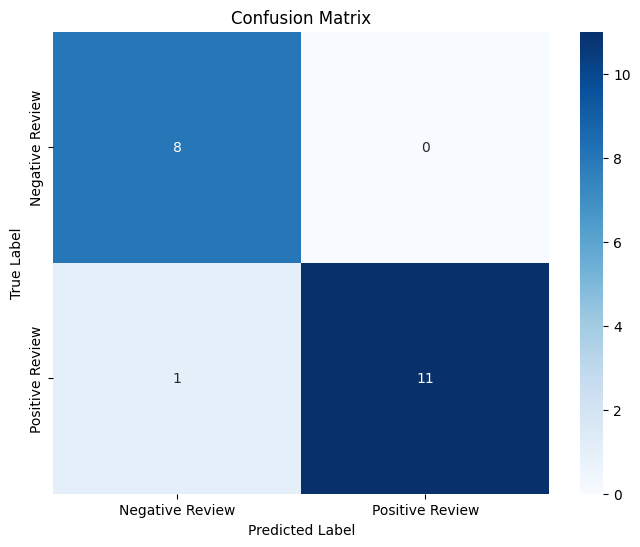

In [24]:
confusion_matrix_data = confusion_matrix(actual_labels, non_pipeline_predictions)
label_values = ['Negative Review', 'Positive Review']


# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_data, annot=True, fmt='d', cmap='Blues', xticklabels=label_values, yticklabels=label_values)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
['Negative Review', 'Positive Review', 'Positive Review', 'Positive Review', 'Negative Review', 'Positive Review', 'Negative Review', 'Negative Review', 'Positive Review', 'Positive Review', 'Negative Review', 'Positive Review', 'Positive Review', 'Positive Review', 'Negative Review', 'Positive Review', 'Negative Review', 'Negative Review', 'Negative Review', 'Positive Review', 'Positive Review', 'Negative Review', 'Negative Review', 'Positive Review', 'Positive Review', 'Negative Review', 'Negative Review', 'Positive Review', 'Negative Review', 'Negative Review', 'Positive Review', 'Negative Review', 'Positive Review', 'Negative Review', 'Positive Review', 'Negative Review', 'Positive Review', 'Positive Review', 'Positive Review', 'Positive Review', 'Positive Review', 'Positive Review', 'Positive Review', 'Positive Review', 'Negative Review', 'Positive Review', 'Negative Review', 'Positive Review', 'Positive Review', 'Negative Review', 'Negative Review'

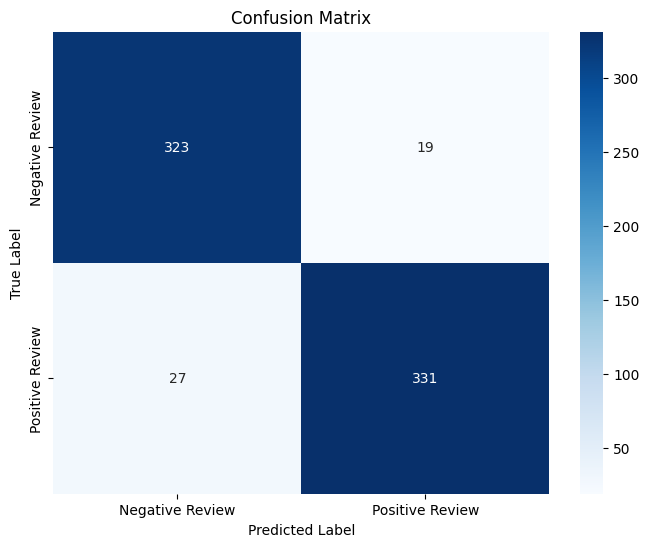

In [25]:
# batched loop
trained_model = AutoModelForSequenceClassification.from_pretrained("IMDB_reviews_dataset_finetuned_sentence_transformer")
sentence_transformer_tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-mpnet-base-v2")

# I convert tokenized_imdb_test_ds datasets object to pandas DataFrame object
# So that I can predict on batches of the data

tokenized_imdb_test_ds_dataframe = tokenized_imdb_test_ds.to_pandas().reset_index()
# print(tokenized_imdb_test_ds_dataframe[95:100])
actual_labels = tokenized_imdb_test_ds_dataframe["review_value"]

batch_size = 50
batch_count = 0

test_set_predictions = []

for i in range(0, len(tokenized_imdb_test_ds_dataframe), batch_size):
  start_index = batch_count * batch_size
  end_index = (batch_count + 1) * batch_size
  batched_data_slice = tokenized_imdb_test_ds_dataframe[start_index:end_index]

  input_ids = batched_data_slice["input_ids"].values
  attention_mask = batched_data_slice["attention_mask"]

  input_ids_list = [torch.from_numpy(array) for array in input_ids]
  # print(input_ids_list)
  input_ids_list_tensor = torch.stack(input_ids_list)
  # print(input_ids_list_tensor)

  attention_mask_list = [torch.from_numpy(array) for array in attention_mask]
  # print(attention_mask_list)
  attention_mask_list_tensor = torch.stack(attention_mask_list)
  # print(attention_mask_list_tensor)

  # print(final_input_ids_list_tensor)
  # print(np.array(input_ids, dtype=int))
  # print(torch.from_numpy(input_ids))
  # print(attention_mask)

  # print(attention_mask_list_tensor)
  with torch.no_grad():
    batched_data_predictions = trained_model(input_ids=input_ids_list_tensor, attention_mask=attention_mask_list_tensor)

  # print(batched_data_predictions.logits)
  prediction_values = batched_data_predictions.logits.argmax(-1)
  test_set_predictions.extend(prediction_values.tolist())

  print(batch_count)
  batch_count += 1

prediction_labels = [id2label.get(i) for i in test_set_predictions]
print(prediction_labels)

confusion_matrix_data = confusion_matrix(actual_labels, prediction_labels)
label_values = ['Negative Review', 'Positive Review']

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_data, annot=True, fmt='d', cmap='Blues', xticklabels=label_values, yticklabels=label_values)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

tensor([1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
        1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0,
        0, 0])


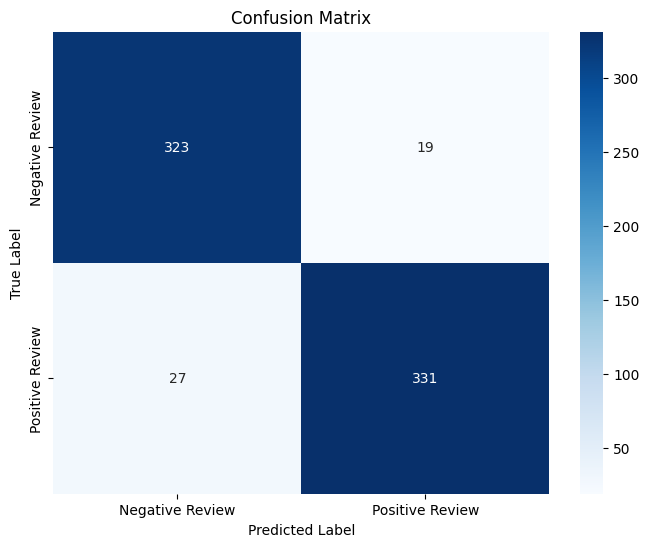

In [26]:
print(prediction_values)
confusion_matrix_data = confusion_matrix(actual_labels, prediction_labels)
label_values = ['Negative Review', 'Positive Review']

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_data, annot=True, fmt='d', cmap='Blues', xticklabels=label_values, yticklabels=label_values)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [27]:
batched_data_predictions

SequenceClassifierOutput(loss=None, logits=tensor([[-1.7160,  1.6883],
        [ 1.7132, -1.7063],
        [-1.7011,  1.6796],
        [-1.7285,  1.7145],
        [ 1.7183, -1.7357],
        [ 1.6318, -1.6864],
        [ 1.7197, -1.7340],
        [ 1.7053, -1.7064],
        [ 1.7234, -1.7302],
        [-1.7210,  1.7154],
        [ 1.7003, -1.7257],
        [ 1.7285, -1.7385],
        [ 1.7260, -1.7373],
        [ 1.7281, -1.7282],
        [ 1.7240, -1.7207],
        [ 1.7190, -1.7212],
        [-1.7357,  1.7093],
        [ 1.6719, -1.6591],
        [-1.7310,  1.7172],
        [-1.7177,  1.6994],
        [ 1.7193, -1.7238],
        [ 1.7085, -1.7063],
        [ 1.7071, -1.7434],
        [ 1.7257, -1.7391],
        [-1.7387,  1.7202],
        [ 1.7319, -1.7402],
        [ 1.7181, -1.7393],
        [ 1.7257, -1.7326],
        [-1.7338,  1.7068],
        [-1.7282,  1.7060],
        [-1.7377,  1.7144],
        [ 1.7245, -1.7318],
        [-1.7329,  1.7178],
        [ 1.7318, -1.7409],
     

In [28]:
print(test_set_predictions)

[0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 